NAIMA SHARIFF

HW0: PROBLEM 4

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.sparse as sp
import scipy.sparse.linalg as spla

#Plot styling
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['lines.linewidth'] = 3


In [28]:
#Global parameters
xmin, xmax = 0, 5
ymin, ymax = 0, 5
nx, ny = 50, 50

#Dense, log-spaced sequence of grid sizes for a smooth convergence curve
n_values = np.unique(np.round(np.geomspace(5, 320, 13)).astype(int))


In [29]:
#Exact solution, forcing function, index mapping, and the linear system builder
def u_exact(x, y):
    return np.sin(x) * np.cos(y)

def f_exact(x, y):
    # laplacian of sin(x)cos(y): u_xx + u_yy = -sin(x)cos(y) - sin(x)cos(y) = -2 sin(x)cos(y)
    return -2 * np.sin(x) * np.cos(y)

def u_x_exact(x, y):
    return np.cos(x) * np.cos(y)

def u_y_exact(x, y):
    return -np.sin(x) * np.sin(y)

def idx(i, j, nx):
    return i + j * nx

def build_system(nx, ny):
    #Assumes a square grid (hx == hy)
    h = (xmax - xmin) / (nx - 1)
    x = np.linspace(xmin, xmax, nx)
    y = np.linspace(ymin, ymax, ny)

    N = nx * ny
    row, col, val = [], [], []
    rhs = np.zeros(N)

    #Interior-point method: loop over every grid point
    for j in range(ny):
        for i in range(nx):
            k = idx(i, j, nx)

            if i == 0 or i == nx - 1 or j == 0 or j == ny - 1:
                #Dirichlet boundary row: u_k = u_exact(x_i, y_j)
                row.append(k); col.append(k); val.append(1.0)
                rhs[k] = u_exact(x[i], y[j])
            else:
                #Interior row: 5-point Laplacian stencil, multiplied through by h^2
                row.append(k); col.append(idx(i - 1, j, nx)); val.append(1.0)
                row.append(k); col.append(idx(i + 1, j, nx)); val.append(1.0)
                row.append(k); col.append(idx(i, j - 1, nx)); val.append(1.0)
                row.append(k); col.append(idx(i, j + 1, nx)); val.append(1.0)
                row.append(k); col.append(k);                 val.append(-4.0)
                rhs[k] = h**2 * f_exact(x[i], y[j])

    A = sp.coo_matrix((val, (row, col)), shape=(N, N)).tocsc()
    return x, y, A, rhs

def build_system_neumann(nx, ny):
    #Neumann boundary conditions: u_x = u_x_exact, u_y = u_y_exact on the boundary
    h = (xmax - xmin) / (nx - 1)
    x = np.linspace(xmin, xmax, nx)
    y = np.linspace(ymin, ymax, ny)

    N = nx * ny
    row, col, val = [], [], []
    rhs = np.zeros(N)

    for j in range(ny):
        for i in range(nx):
            k = idx(i, j, nx)

            if i == 0:
                row.append(k); col.append(k); val.append(-1.0 / h)
                row.append(k); col.append(idx(1, j, nx)); val.append(1.0 / h)
                rhs[k] = u_x_exact(x[i], y[j])
            elif i == nx - 1:
                row.append(k); col.append(k); val.append(1.0 / h)
                row.append(k); col.append(idx(nx - 2, j, nx)); val.append(-1.0 / h)
                rhs[k] = u_x_exact(x[i], y[j])
            elif j == 0:
                row.append(k); col.append(k); val.append(-1.0 / h)
                row.append(k); col.append(idx(i, 1, nx)); val.append(1.0 / h)
                rhs[k] = u_y_exact(x[i], y[j])
            elif j == ny - 1:
                row.append(k); col.append(k); val.append(1.0 / h)
                row.append(k); col.append(idx(i, ny - 2, nx)); val.append(-1.0 / h)
                rhs[k] = u_y_exact(x[i], y[j])
            else:
                row.append(k); col.append(idx(i - 1, j, nx)); val.append(1.0)
                row.append(k); col.append(idx(i + 1, j, nx)); val.append(1.0)
                row.append(k); col.append(idx(i, j - 1, nx)); val.append(1.0)
                row.append(k); col.append(idx(i, j + 1, nx)); val.append(1.0)
                row.append(k); col.append(k);                 val.append(-4.0)
                rhs[k] = h**2 * f_exact(x[i], y[j])

    A = sp.coo_matrix((val, (row, col)), shape=(N, N)).tocsc()
    return x, y, A, rhs

def build_system_neumann_fixed(nx, ny):
    #Same as build_system_neumann, but one interior point is pinned with a Dirichlet
    #condition to remove the additive-constant null space.
    h = (xmax - xmin) / (nx - 1)
    x = np.linspace(xmin, xmax, nx)
    y = np.linspace(ymin, ymax, ny)

    N = nx * ny
    row, col, val = [], [], []
    rhs = np.zeros(N)
    pin_i, pin_j = nx // 2, ny // 2

    for j in range(ny):
        for i in range(nx):
            k = idx(i, j, nx)

            if i == pin_i and j == pin_j:
                #Pin one interior point to remove the additive-constant ambiguity
                row.append(k); col.append(k); val.append(1.0)
                rhs[k] = u_exact(x[i], y[j])
            elif i == 0:
                row.append(k); col.append(k); val.append(-1.0 / h)
                row.append(k); col.append(idx(1, j, nx)); val.append(1.0 / h)
                rhs[k] = u_x_exact(x[i], y[j])
            elif i == nx - 1:
                row.append(k); col.append(k); val.append(1.0 / h)
                row.append(k); col.append(idx(nx - 2, j, nx)); val.append(-1.0 / h)
                rhs[k] = u_x_exact(x[i], y[j])
            elif j == 0:
                row.append(k); col.append(k); val.append(-1.0 / h)
                row.append(k); col.append(idx(i, 1, nx)); val.append(1.0 / h)
                rhs[k] = u_y_exact(x[i], y[j])
            elif j == ny - 1:
                row.append(k); col.append(k); val.append(1.0 / h)
                row.append(k); col.append(idx(i, ny - 2, nx)); val.append(-1.0 / h)
                rhs[k] = u_y_exact(x[i], y[j])
            else:
                row.append(k); col.append(idx(i - 1, j, nx)); val.append(1.0)
                row.append(k); col.append(idx(i + 1, j, nx)); val.append(1.0)
                row.append(k); col.append(idx(i, j - 1, nx)); val.append(1.0)
                row.append(k); col.append(idx(i, j + 1, nx)); val.append(1.0)
                row.append(k); col.append(k);                 val.append(-4.0)
                rhs[k] = h**2 * f_exact(x[i], y[j])

    A = sp.coo_matrix((val, (row, col)), shape=(N, N)).tocsc()
    return x, y, A, rhs


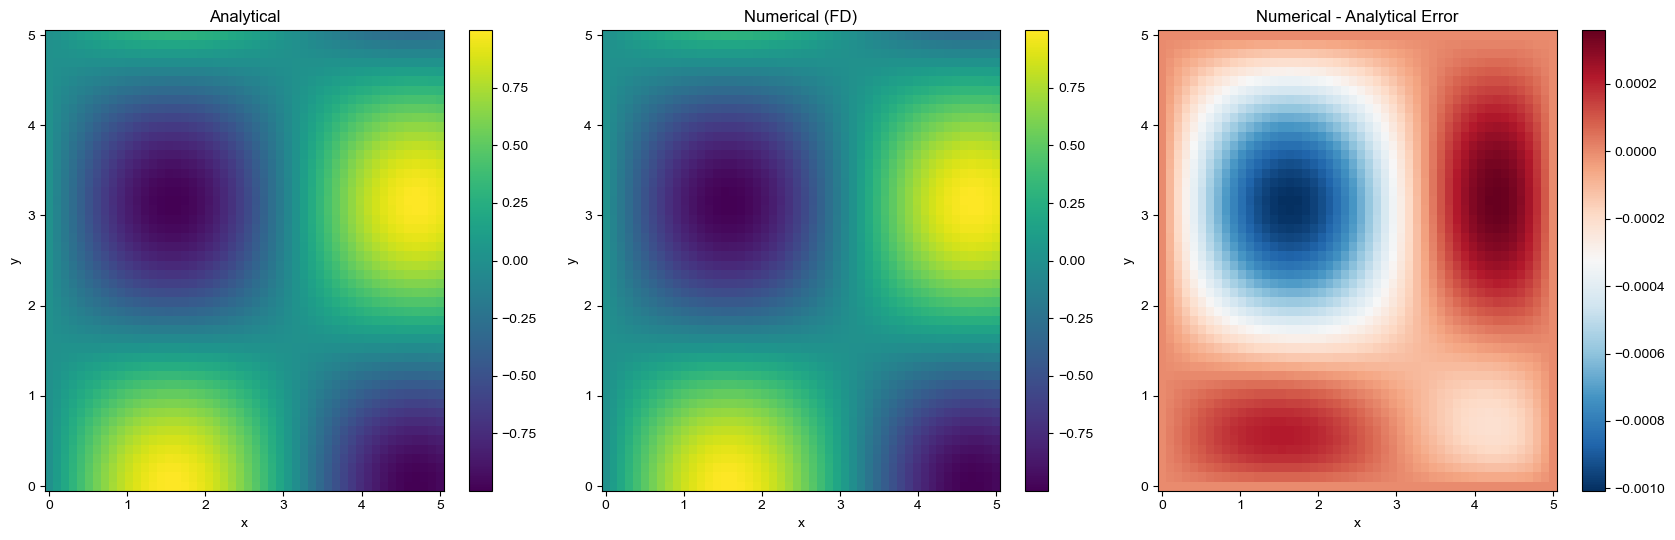

In [30]:
#Solve on the base grid and compare to the analytical solution
x, y, A, rhs = build_system(nx, ny)
u = spla.spsolve(A, rhs)

X, Y = np.meshgrid(x, y)
U_num = u.reshape(ny, nx)
U_exact = u_exact(X, Y)

fig, axes = plt.subplots(1, 3, figsize=(17, 5.5))

c0 = axes[0].pcolormesh(X, Y, U_exact, shading="auto", cmap="viridis")
axes[0].set_title("Analytical")
fig.colorbar(c0, ax=axes[0])

c1 = axes[1].pcolormesh(X, Y, U_num, shading="auto", cmap="viridis")
axes[1].set_title("Numerical (FD)")
fig.colorbar(c1, ax=axes[1])

c2 = axes[2].pcolormesh(X, Y, U_num - U_exact, shading="auto", cmap="RdBu_r")
axes[2].set_title("Numerical - Analytical Error")
fig.colorbar(c2, ax=axes[2])

for ax in axes:
    ax.set_xlabel("x")
    ax.set_ylabel("y")

plt.tight_layout()
plt.savefig("figures/problem4_solution_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


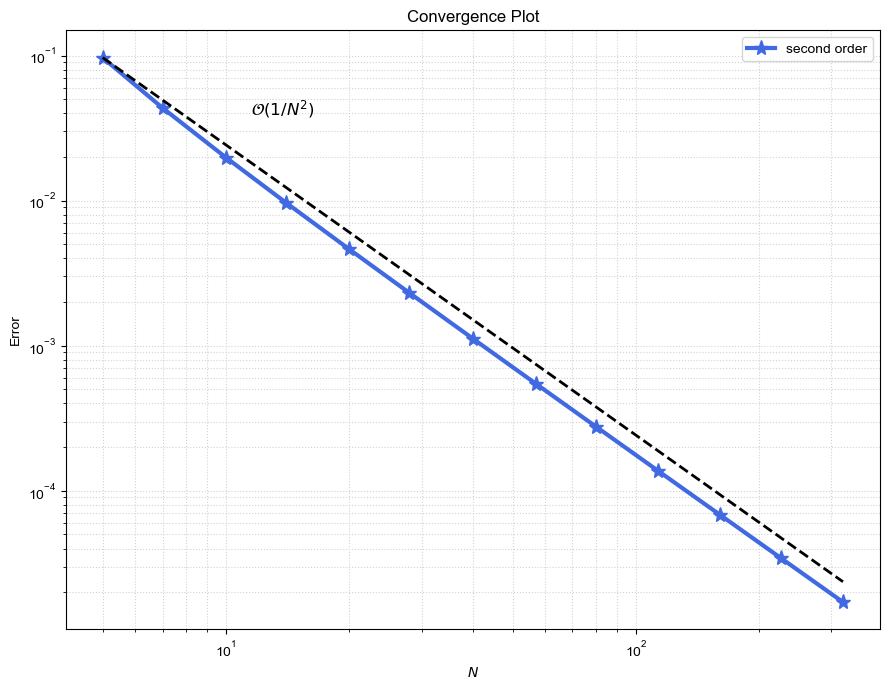

In [31]:
#Convergence study: L2 relative error vs grid size N (square grid, nx = ny = N)
error_l2 = []

for N in n_values:
    xn, yn, An, rhsn = build_system(N, N)
    un = spla.spsolve(An, rhsn)
    Xn, Yn = np.meshgrid(xn, yn)
    exact = u_exact(Xn, Yn).ravel()

    err = un - exact
    error_l2.append(np.linalg.norm(err, ord=2) / np.linalg.norm(exact, ord=2))

error_l2 = np.array(error_l2)
reference = error_l2[0] * (n_values[0] / n_values) ** 2

fig, ax = plt.subplots(figsize=(9, 7))

ax.loglog(n_values, error_l2, "*-", color="royalblue", markersize=11, label="second order")
ax.loglog(n_values, reference, "--", color="black", linewidth=2)


anchor = 2
ax.annotate(
    r"$\mathcal{O}(1/N^2)$",
    xy=(n_values[anchor], reference[anchor]),
    xytext=(18, 22),
    textcoords="offset points",
    fontsize=12,
)

ax.set_xlabel(r"$N$")
ax.set_ylabel("Error")
ax.set_title("Convergence Plot")
ax.grid(True, which="both", linestyle=":", color="lightgray")
ax.legend(loc="upper right", frameon=True)

plt.tight_layout()
plt.savefig("figures/problem4_convergence.png", dpi=150, bbox_inches="tight")
plt.show()


In [26]:
#Part 2: apply Neumann conditions on all boundaries and observe the failure
import warnings

N_demo = 20
_, _, A_neumann, rhs_neumann = build_system_neumann(N_demo, N_demo)

#Linear-algebra symptom: every row's coefficients sum to zero (interior: 1+1+1+1-4=0;
#boundary: 1/h - 1/h = 0), so the constant vector lies in the null space of A
null_check = A_neumann @ np.ones(A_neumann.shape[0])
print("max |A @ ones| =", np.max(np.abs(null_check)))

#Attempt to solve the singular system anyway
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    u_neumann = spla.spsolve(A_neumann, rhs_neumann)
    for w in caught:
        print(f"{w.category.__name__}: {w.message}")

print("solution norm:", np.linalg.norm(u_neumann))
print("contains NaN/Inf:", not np.all(np.isfinite(u_neumann)))


max |A @ ones| = 0.0
solution norm: 2696567699498798.0
contains NaN/Inf: False


### Why pure Neumann conditions fail

Every row's coefficients sum to zero (interior: $1+1+1+1-4=0$; Neumann boundary: $\pm1/h \mp 1/h=0$), so the constant vector is exactly in the null space of $A$ — the matrix is singular, confirmed by `max |A @ ones| = 0.0` above. `spsolve` doesn't error on this; it silently returns a nonsense solution with norm $\sim10^{15}$. This matches the PDE itself: a pure-Neumann Poisson problem requires $\int_\Omega f\,dA = \oint_{\partial\Omega}\partial u/\partial n\,ds$ to have a solution at all, and even then $u$ is only defined up to an arbitrary additive constant — exactly the null direction found above.

**Fix:** pin $u$ at one grid point (Dirichlet) to remove the null space. This only works if the pinned point is interior (or a non-corner boundary point) — pinning a corner leaves the matrix rank-deficient by 1, as verified directly.

*This explanation and suggested fix was developed with the assistance of Claude (Anthropic).*


In [27]:
#Fix: pin one point to remove the null space, then re-solve
x_fixed, y_fixed, A_fixed, rhs_fixed = build_system_neumann_fixed(N_demo, N_demo)

null_check_fixed = A_fixed @ np.ones(A_fixed.shape[0])
print("max |A_fixed @ ones| =", np.max(np.abs(null_check_fixed)))

u_fixed = spla.spsolve(A_fixed, rhs_fixed)

X_fixed, Y_fixed = np.meshgrid(x_fixed, y_fixed)
exact_fixed = u_exact(X_fixed, Y_fixed).ravel()
error_fixed = u_fixed - exact_fixed

print("solution norm:", np.linalg.norm(u_fixed))
print("L2 relative error vs analytical:", np.linalg.norm(error_fixed) / np.linalg.norm(exact_fixed))


max |A_fixed @ ones| = 1.0
solution norm: 9.757688045897808
L2 relative error vs analytical: 0.32771622526493077
